<a href="https://colab.research.google.com/github/gayathrik18/netflix-analysis/blob/main/netflix_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [27]:
import pandas as pd
import numpy as np

In [28]:
from google.colab import files

uploaded = files.upload()

Saving netflix_titles.csv to netflix_titles (1).csv


In [29]:
df = pd.read_csv("netflix_titles.csv")

print(df.head())

  show_id     type                  title         director  \
0      s1    Movie   Dick Johnson Is Dead  Kirsten Johnson   
1      s2  TV Show          Blood & Water              NaN   
2      s3  TV Show              Ganglands  Julien Leclercq   
3      s4  TV Show  Jailbirds New Orleans              NaN   
4      s5  TV Show           Kota Factory              NaN   

                                                cast        country  \
0                                                NaN  United States   
1  Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...   South Africa   
2  Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...            NaN   
3                                                NaN            NaN   
4  Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...          India   

           date_added  release_year rating   duration  \
0  September 25, 2021          2020  PG-13     90 min   
1  September 24, 2021          2021  TV-MA  2 Seasons   
2  September 24, 2021        

In [30]:
print(df.shape)

print(df.columns)

print(df.info())

(8807, 12)
Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB
None


In [31]:
movie_tv = df["type"].value_counts()

print(movie_tv)

type
Movie      6131
TV Show    2676
Name: count, dtype: int64


In [32]:
print(df.isnull().sum())

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64


In [33]:
df["director"] = df["director"].fillna("Unknown")
df["cast"] = df["cast"].fillna("Unknown")
df["country"] = df["country"].fillna("Unknown")
df["rating"] = df["rating"].fillna("Not Rated")

In [34]:
print(df["rating"].value_counts().head(10))

rating
TV-MA    3207
TV-14    2160
TV-PG     863
R         799
PG-13     490
TV-Y7     334
TV-Y      307
PG        287
TV-G      220
NR         80
Name: count, dtype: int64


In [35]:
top_countries = df["country"].value_counts().head(10)

print(top_countries)

country
United States     2818
India              972
Unknown            831
United Kingdom     419
Japan              245
South Korea        199
Canada             181
Spain              145
France             124
Mexico             110
Name: count, dtype: int64


In [36]:
df["date_added"] = pd.to_datetime(
    df["date_added"],
    errors="coerce"
)

df["year_added"] = df["date_added"].dt.year

print(df["year_added"].value_counts().sort_index())

year_added
2008.0       2
2009.0       2
2010.0       1
2011.0      13
2012.0       3
2013.0      10
2014.0      23
2015.0      73
2016.0     418
2017.0    1164
2018.0    1625
2019.0    1999
2020.0    1878
2021.0    1498
Name: count, dtype: int64


In [37]:
oldest = df.sort_values(
    by="release_year"
)

print(oldest[
    ["title","release_year"]
].head(10))

                                                 title  release_year
4250                 Pioneers: First Women Filmmakers*          1925
7790                                    Prelude to War          1942
8205                              The Battle of Midway          1942
8739                Why We Fight: The Battle of Russia          1943
8763                   WWII: Report from the Aleutians          1943
8660     Undercover: How to Operate Behind Enemy Lines          1943
8419  The Memphis Belle: A Story of a\nFlying Fortress          1944
8436                                 The Negro Soldier          1944
8640                                  Tunisian Victory          1944
7219                           Know Your Enemy - Japan          1945


In [38]:
newest = df.sort_values(
    by="release_year",
    ascending=False
)

print(newest[
    ["title","release_year"]
].head(10))

                                              title  release_year
1                                     Blood & Water          2021
2                                         Ganglands          2021
3                             Jailbirds New Orleans          2021
31                               Chicago Party Aunt          2021
30                                  Ankahi Kahaniya          2021
25                             Love on the Spectrum          2021
23     Go! Go! Cory Carson: Chrissy Takes the Wheel          2021
20  Monsters Inside: The 24 Faces of Billy Milligan          2021
19                                           Jaguar          2021
18                                        Intrusion          2021


In [39]:
genres = df["listed_in"].str.split(",")

all_genres = []

for genre_list in genres:
    for genre in genre_list:
        all_genres.append(genre.strip())

genre_series = pd.Series(all_genres)

print(
    genre_series.value_counts().head(10)
)

International Movies        2752
Dramas                      2427
Comedies                    1674
International TV Shows      1351
Documentaries                869
Action & Adventure           859
TV Dramas                    763
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
Name: count, dtype: int64


In [40]:
recent_movies = df[
    df["release_year"] >= 2020
]

print(
    recent_movies[
        ["title","release_year"]
    ].head()
)

                   title  release_year
0   Dick Johnson Is Dead          2020
1          Blood & Water          2021
2              Ganglands          2021
3  Jailbirds New Orleans          2021
4           Kota Factory          2021


In [41]:
india = df[
    df["country"].str.contains(
        "India",
        na=False
    )
]

print(india.shape)

print(
    india[
        ["title","country"]
    ].head()
)

(1046, 13)
            title                       country
4    Kota Factory                         India
24          Jeans                         India
29       Paranoia  United States, India, France
39   Chhota Bheem                         India
50  Dharmakshetra                         India


In [42]:
print(
    df["release_year"].describe()
)

count    8807.000000
mean     2014.180198
std         8.819312
min      1925.000000
25%      2013.000000
50%      2017.000000
75%      2019.000000
max      2021.000000
Name: release_year, dtype: float64


In [43]:
print("Total Titles:", len(df))

print(
    "Movies:",
    len(df[df["type"]=="Movie"])
)

print(
    "TV Shows:",
    len(df[df["type"]=="TV Show"])
)

Total Titles: 8807
Movies: 6131
TV Shows: 2676


In [44]:
df.to_csv(
    "cleaned_netflix_data.csv",
    index=False
)

print("File Saved")

File Saved


In [45]:
import matplotlib.pyplot as plt

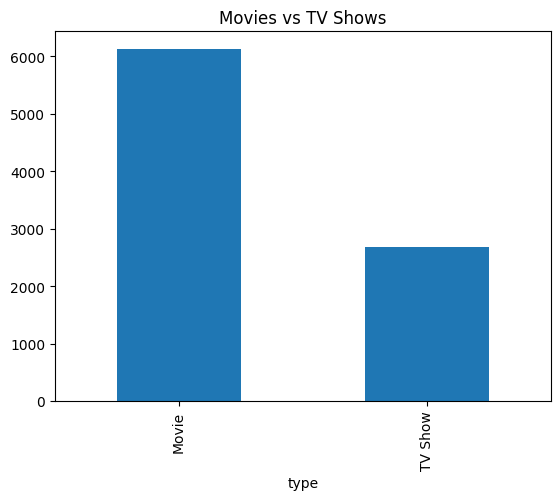

In [46]:
df["type"].value_counts().plot(
    kind="bar"
)

plt.title(
    "Movies vs TV Shows"
)

plt.show()

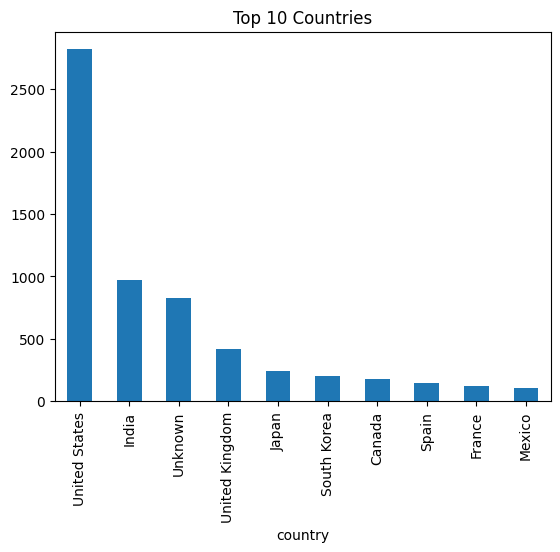

In [47]:
df["country"].value_counts()\
.head(10)\
.plot(kind="bar")

plt.title(
    "Top 10 Countries"
)

plt.show()

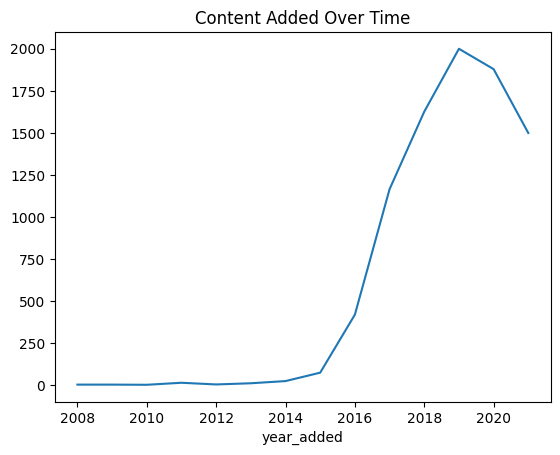

In [48]:
df["year_added"]\
.value_counts()\
.sort_index()\
.plot()

plt.title(
    "Content Added Over Time"
)

plt.show()